In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle('../sim/data/df.pkl')

In [3]:
# df = df[~df['commission'].isna()].copy()

In [4]:
# df = df[df['stage_final'].isin(['Closed Won', 'Closed Lost'])].copy()

In [5]:
# df = df.reset_index(drop = True)
df

,run_id,entity,rep_id,is_lead,won,stage_final,revenue,commission,n_stages,pipeline_depth,...,sentiment_range,frac_send_email,frac_make_call,frac_hold_meeting,frac_follow_up,frac_send_proposal,frac_internal_prep,frac_research_account,frac_solution_design,frac_stakeholder_alignment
0,0,BAIZSUOO_0,005ak00000TI49JAAT,True,False,Closed Dead,4.072784e+06,NaN,2,0.000000,...,3.712332,0.218045,0.112782,0.150376,0.180451,0.0,0.157895,0.180451,0.00,0.0
1,0,WBQHE8N1_0,005ak00000TI4KbAAL,True,False,Closed Lost,7.719355e+06,NaN,2,0.000000,...,3.320825,0.269231,0.269231,0.076923,0.115385,0.0,0.076923,0.192308,0.00,0.0
2,0,KIZKD2NC_0,005ak00000TI49JAAT,True,False,Closed Dead,4.816872e+06,NaN,2,0.000000,...,2.778847,0.214286,0.125000,0.142857,0.160714,0.0,0.196429,0.160714,0.00,0.0
3,0,SGGBZV1F_0,005ak00000TI49JAAT,True,False,Closed Lost,6.860245e+06,NaN,2,0.000000,...,2.619922,0.129032,0.129032,0.258065,0.129032,0.0,0.193548,0.161290,0.00,0.0
4,0,H4ZCOZ7G_0,005ak00000TI49JAAT,True,False,Closed Lost,9.568894e+04,NaN,2,0.000000,...,5.000000,0.221477,0.120805,0.187919,0.161074,0.0,0.255034,0.053691,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2897,4,255e8848-fee2-4b7d-8041-ac30555af6c3_4,005ak00000TI4KbAAL,False,False,Proposal,1.252225e+05,6261.12,2,0.666667,...,4.491196,0.280000,0.160000,0.220000,0.020000,0.1,0.080000,0.060000,0.08,0.0
2898,4,9fd895a7-41f8-4d33-a617-863dba19cf0c_4,005ak00000TI3rZAAT,False,False,Prospecting,4.011798e+04,2005.90,1,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00,0.0
2899,4,b4bc968b-31a9-4662-8076-12b457a74c76_4,005ak00000TI4KbAAL,False,False,Qualification,5.075890e+04,2537.95,2,0.333333,...,1.838943,0.307692,0.153846,0.153846,0.230769,0.0,0.076923,0.076923,0.00,0.0
2900,4,58675fc7-51ab-4530-b96b-ebc09e7d1996_4,005ak00000TI49JAAT,False,False,Prospecting,6.832271e+03,341.61,1,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00,0.0


In [6]:
closed_stages = [
    "Closed Won",
    "Closed Lost",
    "Closed Dead",
    "Closed Converted"
]

df["stage_final"] = df["stage_final"].replace(closed_stages, "Closed")

In [7]:
# One-hot encode stage_final
stage_dummies = pd.get_dummies(df['stage_final'], prefix='stage')
df = pd.concat([df, stage_dummies], axis=1)

# Drop original stage column
df.drop(columns=['stage_final'], inplace=True)

In [8]:
# One-hot encode stage_final
stage_dummies = pd.get_dummies(df['rep_id'], prefix='rep')
df = pd.concat([df, stage_dummies], axis=1)

# Drop original stage column
df.drop(columns=['rep_id'], inplace=True)

In [9]:
df

,run_id,entity,is_lead,won,revenue,commission,n_stages,pipeline_depth,avg_days_in_stage,max_days_in_stage,...,stage_Lead,stage_Lead Qualified,stage_Negotiation,stage_Proposal,stage_Prospecting,stage_Qualification,rep_005ak00000TI0yYAAT,rep_005ak00000TI3rZAAT,rep_005ak00000TI49JAAT,rep_005ak00000TI4KbAAL
0,0,BAIZSUOO_0,True,False,4.072784e+06,NaN,2,0.000000,36.5,72.0,...,0,0,0,0,0,0,0,0,1,0
1,0,WBQHE8N1_0,True,False,7.719355e+06,NaN,2,0.000000,5.5,9.0,...,0,0,0,0,0,0,0,0,0,1
2,0,KIZKD2NC_0,True,False,4.816872e+06,NaN,2,0.000000,17.5,33.0,...,0,0,0,0,0,0,0,0,1,0
3,0,SGGBZV1F_0,True,False,6.860245e+06,NaN,2,0.000000,88.5,172.0,...,0,0,0,0,0,0,0,0,1,0
4,0,H4ZCOZ7G_0,True,False,9.568894e+04,NaN,2,0.000000,28.5,55.0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2897,4,255e8848-fee2-4b7d-8041-ac30555af6c3_4,False,False,1.252225e+05,6261.12,2,0.666667,7.0,7.0,...,0,0,0,1,0,0,0,0,0,1
2898,4,9fd895a7-41f8-4d33-a617-863dba19cf0c_4,False,False,4.011798e+04,2005.90,1,0.000000,0.0,0.0,...,0,0,0,0,1,0,0,1,0,0
2899,4,b4bc968b-31a9-4662-8076-12b457a74c76_4,False,False,5.075890e+04,2537.95,2,0.333333,1.0,1.0,...,0,0,0,0,0,1,0,0,0,1
2900,4,58675fc7-51ab-4530-b96b-ebc09e7d1996_4,False,False,6.832271e+03,341.61,1,0.000000,0.0,0.0,...,0,0,0,0,1,0,0,0,1,0


In [10]:
import numpy as np

In [11]:
min_activity = 3
df['engagement_consistency'] = np.where(
    df['activity_count'] >= min_activity,
    1 - np.abs(df['early_activity'] - df['late_activity']) / df['activity_count'],
    0  # or 0 if you want to count them as 0
)

In [12]:
df = df.drop(columns = ['run_id', 'entity','sentiment_median','sentiment_std', 'n_stages', 'pipeline_depth', 'is_lead' ])

In [13]:
df.columns

Index(['won', 'revenue', 'commission', 'avg_days_in_stage',
       'max_days_in_stage', 'days_in_stage_cv', 'cycle_time', 'activity_count',
       'avg_micro_per_stage', 'early_activity', 'late_activity', 'activity_cv',
       'activity_velocity', 'stage_velocity', 'action_diversity',
       'success_rate', 'momentum_slope', 'touch_recency', 'stall_count',
       'prop_late_actions', 'sentiment_final', 'sentiment_range',
       'frac_send_email', 'frac_make_call', 'frac_hold_meeting',
       'frac_follow_up', 'frac_send_proposal', 'frac_internal_prep',
       'frac_research_account', 'frac_solution_design',
       'frac_stakeholder_alignment', 'stage_Closed', 'stage_Lead',
       'stage_Lead Qualified', 'stage_Negotiation', 'stage_Proposal',
       'stage_Prospecting', 'stage_Qualification', 'rep_005ak00000TI0yYAAT',
       'rep_005ak00000TI3rZAAT', 'rep_005ak00000TI49JAAT',
       'rep_005ak00000TI4KbAAL', 'engagement_consistency'],
      dtype='object')

In [14]:
print(f'n cols = {len(df.columns)}\nn rows = {len(df)}')

n cols = 43
n rows = 2902


In [15]:
len(df)

2902

In [16]:
df['commission'] = df['commission'].fillna(0)

In [17]:
df['momentum_slope'] = df['momentum_slope'].fillna(0)

In [18]:
df.isna().sum()

won                           0
revenue                       0
commission                    0
avg_days_in_stage             0
max_days_in_stage             0
days_in_stage_cv              0
cycle_time                    0
activity_count                0
avg_micro_per_stage           0
early_activity                0
late_activity                 0
activity_cv                   0
activity_velocity             0
stage_velocity                0
action_diversity              0
success_rate                  0
momentum_slope                0
touch_recency                 0
stall_count                   0
prop_late_actions             0
sentiment_final               0
sentiment_range               0
frac_send_email               0
frac_make_call                0
frac_hold_meeting             0
frac_follow_up                0
frac_send_proposal            0
frac_internal_prep            0
frac_research_account         0
frac_solution_design          0
frac_stakeholder_alignment    0
stage_Cl

In [19]:
X = df.drop(columns=['won'])
y = df['won']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=8493,
    max_depth=7,           # or try 8–10 if overfitting
    min_samples_split=15,
    min_samples_leaf=7,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1
)

# rf.fit(X_scaled, df['won'])

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [23]:

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8801652892561983
Precision: 0.625
Recall: 0.9790209790209791
F1 Score: 0.7629427792915531

Confusion Matrix:
 [[499  84]
 [  3 140]]

Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.86      0.92       583
        True       0.62      0.98      0.76       143

    accuracy                           0.88       726
   macro avg       0.81      0.92      0.84       726
weighted avg       0.92      0.88      0.89       726



In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.86      0.92       583
        True       0.62      0.98      0.76       143

    accuracy                           0.88       726
   macro avg       0.81      0.92      0.84       726
weighted avg       0.92      0.88      0.89       726

[[499  84]
 [  3 140]]


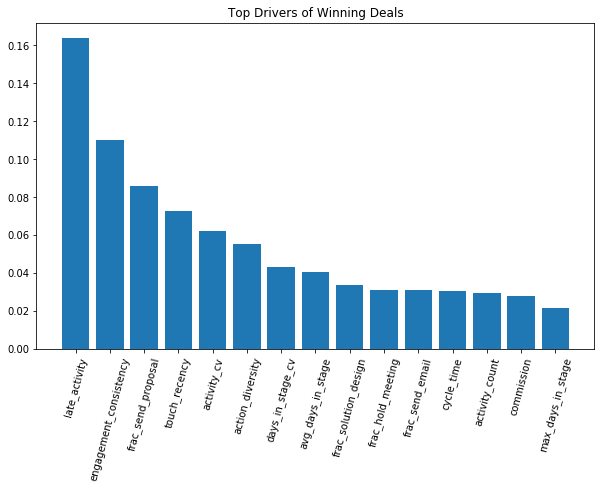

In [25]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10,6))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), features[idx], rotation=75)
plt.title("Top Drivers of Winning Deals")
plt.show()

In [26]:
for feat, imp in zip(features, importances):
    print(feat, imp)

revenue 0.003640446612681512
commission 0.027564432176912446
avg_days_in_stage 0.040465302978976894
max_days_in_stage 0.021252227096147738
days_in_stage_cv 0.043280838983825384
cycle_time 0.030390979079920187
activity_count 0.029305647363273086
avg_micro_per_stage 0.02090357326469599
early_activity 0.008152890644624072
late_activity 0.16364616577254656
activity_cv 0.06226534737484216
activity_velocity 0.011790372713740283
stage_velocity 0.012107579839897119
action_diversity 0.05522647424830535
success_rate 0.005890706604732271
momentum_slope 0.0044722567861937524
touch_recency 0.0725290325000892
stall_count 0.0007858828044915537
prop_late_actions 0.013827358072777721
sentiment_final 0.009517217279676325
sentiment_range 0.009141146117319662
frac_send_email 0.031023343475432695
frac_make_call 0.006431662802761907
frac_hold_meeting 0.03112930283541273
frac_follow_up 0.0020378640447496397
frac_send_proposal 0.08556281682170318
frac_internal_prep 0.006499966955644061
frac_research_account 0

In [27]:
# min_activity = 3
# df['engagement_consistency'] = np.where(
#     df['activity_count'] >= min_activity,
#     1 - np.abs(df['early_activity'] - df['late_activity']) / df['activity_count'],
#     np.nan  # or 0 if you want to count them as 0
# )

(array([982., 244., 157., 101.,  87., 113.,  94., 169., 240., 715.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 10 Patch objects>)

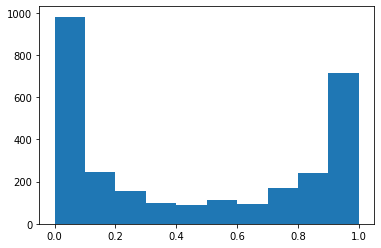

In [28]:
plt.hist(df['engagement_consistency'])

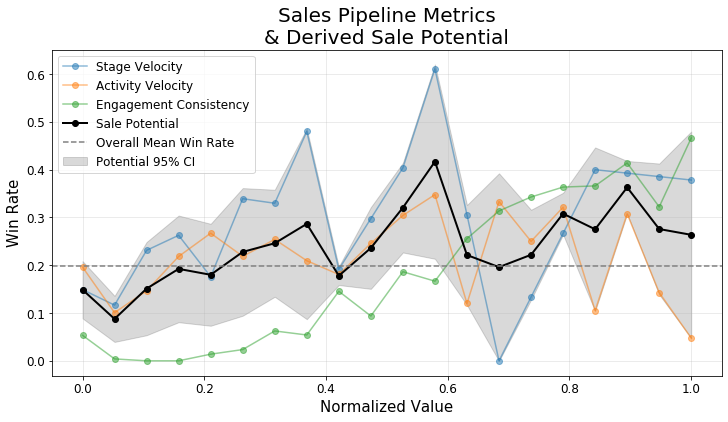

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Clip outliers ---
def clip_outliers(series, lower=0.01, upper=0.99):
    low_val = series.quantile(lower)
    high_val = series.quantile(upper)
    return series.clip(lower=low_val, upper=high_val)

df['stage_clipped'] = clip_outliers(df['stage_velocity'], lower=0.00, upper=0.99)
df['activity_clipped'] = clip_outliers(df['activity_velocity'], lower=0.00, upper=0.99)
df['consistency_clipped'] = clip_outliers(df['engagement_consistency'], lower=0.00, upper=0.99)

# --- Step 2: Normalize 0-1 ---
df['stage_velocity_norm'] = (df['stage_clipped'] - df['stage_clipped'].min()) / (df['stage_clipped'].max() - df['stage_clipped'].min())
df['activity_velocity_norm'] = (df['activity_clipped'] - df['activity_clipped'].min()) / (df['activity_clipped'].max() - df['activity_clipped'].min())
df['engagement_consistency_norm'] = (df['consistency_clipped'] - df['consistency_clipped'].min()) / (df['consistency_clipped'].max() - df['consistency_clipped'].min())

# --- Step 3: Per-bin win rates ---
n_bins = 20
def per_bin_win_rate(series, won, bins):
    bin_idx = np.digitize(series, bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(bins)-2)
    df_tmp = won.groupby(bin_idx).mean()
    df_tmp = df_tmp.reindex(np.arange(len(bins)-1), fill_value=np.nan)
    return df_tmp.interpolate()

stage_bins = np.linspace(df["stage_velocity_norm"].min(), df["stage_velocity_norm"].max(), n_bins+1)
activity_bins = np.linspace(df["activity_velocity_norm"].min(), df["activity_velocity_norm"].max(), n_bins+1)
consistency_bins = np.linspace(df["engagement_consistency_norm"].min(), df["engagement_consistency_norm"].max(), n_bins+1)

stage_win = per_bin_win_rate(df["stage_velocity_norm"], df["won"], stage_bins)
activity_win = per_bin_win_rate(df["activity_velocity_norm"], df["won"], activity_bins)
consistency_win = per_bin_win_rate(df["engagement_consistency_norm"], df["won"], consistency_bins)

# --- Step 4: Compute Sale Potential ---
# Weighted sum of the three metrics' per-bin win rates (simple example)
# You can tweak weights if desired
weights = np.array([0.4, 0.4, 0.2])
sale_potential = (weights[0]*stage_win + weights[1]*activity_win + weights[2]*consistency_win)
# --- Step 4b: Compute Sale Potential and Confidence Interval ---
metric_matrix = np.vstack([stage_win, activity_win, consistency_win])  # shape: (3, n_bins)
weights = np.array([0.4, 0.4, 0.2])

sale_potential = (weights @ metric_matrix)  # weighted sum per bin
# Compute standard deviation across metrics for each bin
potential_std = np.sqrt(np.sum((weights[:, None]**2) * (metric_matrix - metric_matrix.mean(axis=0))**2, axis=0))

# 95% CI (approx) using ±1.96*std
ci_upper = sale_potential + 1.96*potential_std
ci_lower = sale_potential - 1.96*potential_std



# --- Step 5: Plot ---
x_common = np.linspace(0, 1, n_bins)
mean_win = df['won'].mean()

plt.figure(figsize=(12,6))
plt.plot(x_common, stage_win, marker='o', label="Stage Velocity", color='tab:blue', alpha=0.5)
plt.plot(x_common, activity_win, marker='o', label="Activity Velocity", color='tab:orange', alpha=0.5)
plt.plot(x_common, consistency_win, marker='o', label="Engagement Consistency", color='tab:green', alpha=0.5)
plt.plot(x_common, sale_potential, marker='o', label="Sale Potential", color='black', linewidth=2)
plt.fill_between(x_common, ci_lower, ci_upper, color='black', alpha=0.15, label='Potential 95% CI')
# plt.plot(x_common, sale_potential, marker='o', label="Sale Potential", color='black', linewidth=2)
# Overall mean win rate
plt.axhline(mean_win, color='gray', linestyle='--', linewidth=1.5, label='Overall Mean Win Rate')

plt.xlabel("Normalized Value", fontsize=15)
plt.ylabel("Win Rate", fontsize=15)
plt.title("Sales Pipeline Metrics\n& Derived Sale Potential", fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('win_rate_metrix.png')
plt.show()